In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

pd.reset_option("display.max_columns") # this line enables us to see the entire columns in the veiwd data head in the notebook
pd.reset_option('display.max_rows')

In [2]:
data = pd.read_csv("data/nova_pay_combined.csv")

In [3]:
 # to take a snapshot of the dataset
data.head(5)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [4]:
# to see the value counts of our target variables. 
# this is important or checking class imballance. ( We can use SMOT to hendle imballance)

data["is_fraud"].value_counts()

is_fraud
0    10403
1      997
Name: count, dtype: int64

In [5]:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

In [6]:
data['timestamp']

0        2022-10-03 18:40:59.468549+00:00
1        2022-10-03 20:39:38.468549+00:00
2        2022-10-03 23:02:43.468549+00:00
3        2022-10-04 01:08:53.468549+00:00
4        2022-10-04 09:35:03.468549+00:00
                       ...               
11395    2025-11-25 10:05:35.573611+00:00
11396    2025-11-26 07:09:56.573611+00:00
11397    2025-11-27 06:19:11.573611+00:00
11398    2025-11-28 00:53:28.573611+00:00
11399    2025-11-29 20:10:47.573611+00:00
Name: timestamp, Length: 11400, dtype: str

In [7]:
# Checking for null values
null_columns= data.isnull().mean() * 100 > 0

null_columns[null_columns==True].index.to_list()


['timestamp',
 'amount_usd',
 'fee',
 'ip_address',
 'ip_country',
 'kyc_tier',
 'device_trust_score']

- convert Timestamp to datetime
- convert amount_src to numerical

Assignment
- dropping Identifiers
- deal with duplicates
- deal with null values
- fix inconsistencies in categorical variables

In [9]:
# to see the description of the data

data.describe(include=['str', 'bool'])

,transaction_id,customer_id,home_country,source_currency,dest_currency,channel,amount_src,device_id,new_device,ip_address,ip_country,location_mismatch,kyc_tier
count,11400,11400,11400,11400,11400,11400,11400,11400,11400,11095,11099,11400,11100
unique,11200,1315,7,3,9,12,9850,2113,2,10900,9,2,14
top,4662cb2d-21b2-4390-ba38-5a1eddebdc7c,402cccc9-28de-45b3-9af7-cc5302aa1f93,US,USD,NGN,mobile,100,e70db499-19e1-4927-b04f-3ebfcf62e33c,False,194.179.17.152,US,False,standard
freq,2,1510,7940,8031,1474,6366,15,87,10047,2,6848,9548,7931


In [10]:
data.describe()

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.000000,11105.000000,11400.000000,11400.000000,11400.000000,11105.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,452.022083,100.309441,167.540397,0.396726,393.793158,0.653681,0.048509,0.267134,0.458333,0.723509,0.045501,0.087456
std,1403.973062,958.128504,382.023827,0.270507,342.348393,0.273012,0.256194,0.142983,1.524494,1.958390,0.084942,0.282515
min,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,92.465000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,163.480000,3.500000,7.142857,0.325000,298.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,302.190000,5.550000,73.529412,0.487000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [11]:
#  converting timestamps to datetime and make every error value a null
data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')

In [12]:
#  duplicates in time in amount_src nd make every error value a null
data['amount_src'] = pd.to_numeric(data['amount_src'], errors='coerce')

In [13]:
# Checking the dtype of our new columns after convertion
data[['amount_src','timestamp']].dtypes

amount_src                float64
timestamp     datetime64[us, UTC]
dtype: object

In [14]:
data['fee'].dtype

dtype('float64')

In [37]:
for col in data.select_dtypes(include=['str', 'bool']).columns.tolist():
    print(data[col].value_counts())
    print  ("------------------")

transaction_id
4662cb2d-21b2-4390-ba38-5a1eddebdc7c    2
e69d481f-2ee3-4621-a58a-73fec8c63eca    2
8537371a-7eae-4108-89c9-5660e5025a88    2
2e553c23-063e-4b5e-aa2e-8a41d6aa61ca    2
a9198fb0-d831-48df-b434-c30a39078aa3    2
                                       ..
b5ef3323-46d2-4f6c-9c19-43df4e55df48    1
54f00f78-94aa-4a08-bf6b-12877aa47186    1
6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5    1
4aad7389-2b62-4885-a23e-aa3ecd5cfaf9    1
fdffeb16-192a-4483-9b1e-9928e23269c2    1
Name: count, Length: 11200, dtype: int64
------------------
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9856-a5c6109a62e3    1355
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1345
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1066
af8ca4c4-8703-4c55-b66c-2b76cd70040d     915
                                        ... 
8734e6a7-f34e-49f2-b559-1d62a756664c       1
c18070a6-bdb9-4df3-9df7-5d92c0bff424       1
2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca       1
8b1cf558-4ed7-48ee-b330-75db6efd4840       1
b

## Dropping Identifiers





In [15]:
data = data.drop(['transaction_id','customer_id',],axis=1)
data.head(5)

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [16]:
data = data.drop('device_id',axis=1)
data.head(5)

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,True,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,False,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,False,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,False,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


## deal with duplicates

In [50]:
# to detect duplicates
data[data.duplicated()]

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
10000,2024-10-21 18:24:40.468549+00:00,UK,GBP,CNY,mobile,79.41,99.26,1.78,8.928571,False,54.13.217.196,UK,False,0.127,standard,4,0.892,0,0.407,6,6,0.0,0
10001,2023-08-29 10:22:29.468549+00:00,US,USD,GBP,mobile,-320.40,320.40,9999.99,0.800000,False,214.69.54.29,US,False,1.200,standard,1018,-0.100,0,0.087,-1,0,0.0,0
10002,2025-08-25 11:42:34.468549+00:00,US,USD,USD,web,96.37,96.37,2.65,1.000000,False,27.190.57.132,CA,True,0.487,standard,298,0.336,0,0.166,0,0,0.0,0
10003,2025-09-04 08:07:31.468549+00:00,US,USD,GBP,ATM,53.16,53.16,1.66,0.800000,False,73.235.33.228,US,False,0.405,enhanced,257,0.894,0,0.257,0,0,0.0,0
10004,2025-01-27 15:05:01.468549+00:00,US,USD,USD,web,119.97,119.97,2.76,1.000000,False,64.178.230.58,US,False,0.494,standard,263,0.522,0,0.223,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10195,2022-11-25 16:25:46.468549+00:00,US,USD,GBP,mobile,127.91,127.91,2.97,0.800000,False,194.98.205.238,US,False,0.315,standard,1018,0.934,0,0.087,0,0,0.0,0
10196,2023-01-13 16:50:48.468549+00:00,US,USD,CNY,ATM,286.59,286.59,5.12,7.142857,False,141.199.241.52,US,False,0.383,enhanced,257,0.894,0,0.257,0,0,0.0,0
10197,2025-07-02 11:33:48.468549+00:00,US,USD,USD,mobile,230.09,230.09,4.01,1.000000,False,90.83.16.134,US,False,0.244,enhanced,367,0.939,0,0.176,0,0,0.0,0
10198,2023-01-01 02:40:14.468549+00:00,UK,GBP,PHP,mobile,-168.96,211.20,9999.99,73.529412,False,94.169.104.121,UK,False,1.200,standard,4,-0.100,0,0.407,-1,0,0.0,0


In [53]:
data.index.duplicated().sum()

np.int64(0)

# deal with null values


In [17]:
# To check for columns with null values
data.columns[data.isnull().any()].tolist()

['timestamp',
 'amount_src',
 'amount_usd',
 'fee',
 'ip_address',
 'ip_country',
 'kyc_tier',
 'device_trust_score']

In [18]:
# To show columns and number of nulls in each
data.isnull().sum()[data.isnull().sum()>0]

timestamp              61
amount_src              4
amount_usd            305
fee                   295
ip_address            305
ip_country            301
kyc_tier              300
device_trust_score    295
dtype: int64

In [62]:
# To check the percentage of nulls per columns
(data.isnull().mean()*100).sort_values(ascending=False)

amount_usd                   2.675439
ip_address                   2.675439
ip_country                   2.640351
kyc_tier                     2.631579
fee                          2.587719
device_trust_score           2.587719
timestamp                    0.535088
amount_src                   0.035088
channel                      0.000000
home_country                 0.000000
source_currency              0.000000
dest_currency                0.000000
new_device                   0.000000
location_mismatch            0.000000
exchange_rate_src_to_dest    0.000000
ip_risk_score                0.000000
account_age_days             0.000000
chargeback_history_count     0.000000
risk_score_internal          0.000000
txn_velocity_1h              0.000000
txn_velocity_24h             0.000000
corridor_risk                0.000000
is_fraud                     0.000000
dtype: float64

In [19]:
# Dealing with null values in timestamps
"""
We shall drop columns with null  values since 
the percentage of nulls is just o.5%
"""

data = data.dropna(subset=['timestamp'])

In [20]:
# Dealing with null values in amount_src
"""
We shall drop columns with null  values since 
the percentage of nulls is just o.03%
"""
data = data.dropna(subset=['amount_src'])


In [21]:
# dealing with nulls in amoount_usd
"""
here we shall recalculate the entire columns
in order to fill in the nulls. 
To find the amount in usd, 
amount_usd = amount_src * exchange rate
"""
data['amount_usd'] = data['amount_src'] * data['exchange_rate_src_to_dest']


In [25]:
data

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,3.759323e+02,4.25,1.351351,False,...,0.123,standard,263,0.522,0,0.223,0,0,0.00,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,2.660300e+03,4.24,12.758621,True,...,0.569,standard,947,0.475,0,0.268,0,1,0.00,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,1.145214e+03,2.70,7.142857,False,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.00,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,5.500926e+01,2.22,0.925926,False,...,0.594,standard,147,0.551,0,0.391,0,0,0.00,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,1.674667e+04,3.61,83.333333,False,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11395,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,3.665540e+02,5.24,1.351351,False,...,0.307,standard,742,0.653,0,0.302,1,2,0.00,0
11396,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,4.416731e+05,8.86,822.222222,False,...,0.891,low,9,0.173,2,0.730,3,6,0.00,1
11397,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,1.265092e+04,4.00,61.666667,True,...,1.000,low,21,0.269,1,0.605,3,4,0.12,1
11398,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,4.590000e+03,1.96,58.823529,False,...,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0


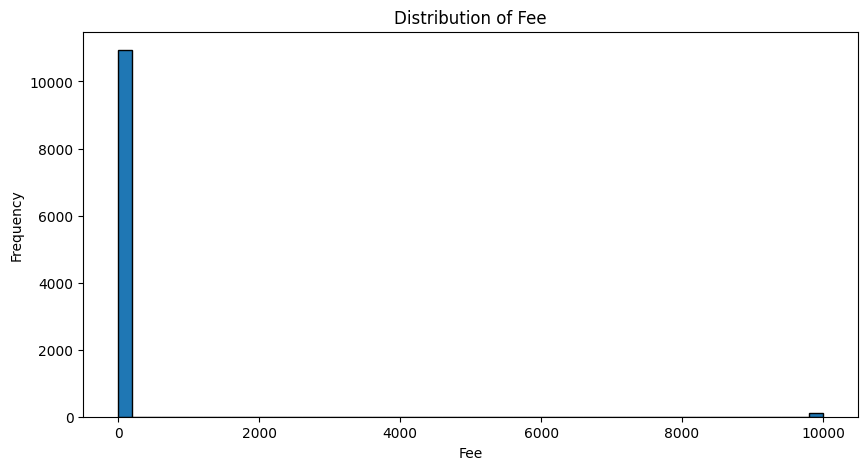

In [31]:
# To veiw the distrubutions of various columns in the dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(data['fee'], bins=50, edgecolor='black')
plt.title('Distribution of Fee')
plt.xlabel('Fee')
plt.ylabel('Frequency')
plt.show()


In [ ]:
# Correction for dealing with nulls in amoount_usd
"""
We need to recalculate the clomn and input it with it.
1. first find the exchange rate between the amount_src and usd.
2. we do the conversion: amount_src * usd_ex_rate
"""

In [32]:
# deal with nulls in fee 
"""
We nee to decide how to replace the null (either with mean, median or mode).
to do this :
Since we dont know the fees formula, we use median to imput

"""
data['fee'] = data.groupby(['source_currency', 'dest_currency'])['fee'].transform(lambda x: x.fillna(x.median()))

In [ ]:
# Correction for deal with nulls in fee 
"""
we need to group the fee according channel and find the mean fee for each channel
and used the mean for each channel to fill in the null.
"""

In [76]:
# Dealling with missing IPs
"""
it is important that we dont drop those columns because missing
IP is an indication of fraud. therefore we create a new feature 
to represent missing and non-missing IP. then we fill the null 
with a placeholder (0.0.0.0)

"""
# This creates a new feature
data['ip_missing'] = data['ip_address'].isnull().astype(int) 

# This fills the null with placeholder(0.0.0.0)
data['ip_address']= data['ip_address'].fillna('0.0.0.0')



In [ ]:
# deal with missing ip_country
"""
we dont drop those rows because missing ip country is meaningful
 to dertermining fraud. so we create a new feature for missing ip country
 and replace null with placeholder (unknown)

"""
data['ip_country_missing'] = data['ip_country'].isnull().astype(int)

data['ip_country'] = data['ip_country'].fillna('unknown')

In [34]:
# Deal with kyc_tier 
"""
A missing KYC is a strong indicator for fraud. 
we create a new feature to represent it and replace null with a place holder

"""

data['kyc_tier_missing'] = data['kyc_tier'].isnull().astype(int)

data['kyc_tier'] = data['kyc_tier'].fillna('unknown')

In [35]:
# deal with missing device_trust_score
"""
missing device trust score means that the device was unverified
We creat a missing flag (new feature ) for it and replace null
with median. 
"""

data['device_trustScore_missing'] = data['device_trust_score'].isnull().astype(int)

data['device_trust_score'] = data['device_trust_score'].fillna(data['device_trust_score'].median())

# fix inconsistencies in categorical variables

In [36]:
# To fix inconsistencies in the categorical variabels which comes as a result of spaces in names
#To take away the spaces
data['kyc_tier'] = data['kyc_tier'].astype(str).str.strip()
data['channel'] = data['channel'].astype(str).str.strip()
data['home_country'] = data['home_country'].astype(str).str.strip()
data['ip_country'] = data['ip_country'].astype(str).str.strip()


In [37]:
# To remove inconsistent capitalisation
data['kyc_tier'] = data['kyc_tier'].str.lower()
data['channel'] = data['channel'].str.lower()
data['home_country'] = data['home_country'].str.upper()   # country codes should be uppercase
data['ip_country'] = data['ip_country'].str.upper()


In [38]:
for col in data.select_dtypes(include=['str', 'bool']).columns.tolist():
    print(data[col].value_counts())
    print  ("------------------")

home_country
US         7962
UK         2119
CA         1222
UNKNOWN      32
Name: count, dtype: int64
------------------
source_currency
USD    7985
GBP    2126
CAD    1224
Name: count, dtype: int64
------------------
dest_currency
NGN    1468
USD    1320
CNY    1316
INR    1315
PHP    1309
GBP    1288
CAD    1275
EUR    1188
MXN     856
Name: count, dtype: int64
------------------
channel
mobile     6421
web        3779
atm        1014
mobille      60
unknown      37
weeb         24
Name: count, dtype: int64
------------------
new_device
False    9989
True     1346
Name: count, dtype: int64
------------------
ip_address
194.179.17.152     2
165.110.247.200    2
24.73.140.66       2
240.36.95.84       2
5.134.140.197      2
                  ..
221.126.239.197    1
26.6.123.44        1
184.150.56.237     1
31.125.175.93      1
216.205.157.160    1
Name: count, Length: 10836, dtype: int64
------------------
ip_country
US         6859
UK         2410
CA         1730
UNKNOWN     333
NAN 

In [39]:
# Fix misspellings and variants
# 1. KYC tier mapping
kyc_map = {
    'standard': 'standard',
    'standrd': 'standard',
    ' standard': 'standard',
    'STANDARD': 'standard',
    'enhanced': 'enhanced',
    ' enhanced': 'enhanced',
    'enhancd': 'enhanced',
    'ENHANCED': 'enhanced',
    'low': 'low',
    ' low': 'low',
    'LOW': 'low',
    'nan': 'unknown',
    'NAN': 'unknown',
    'unknown': 'unknown'
}

data['kyc_tier'] = data['kyc_tier'].map(kyc_map)





# 2. Channel mapping
channel_map = {
    'mobile': 'mobile',
    'mobille': 'mobile',
    'MOBILE': 'mobile',
    'web': 'web',
    'WEB': 'web',
    'weeb': 'web',
    'atm': 'atm',
    'ATm': 'atm',
    'ATM': 'atm',
    'unknown': 'unknown'
}

data['channel'] = data['channel'].str.lower().map(channel_map)


# 3. Country mapping

country_map = {
    'US': 'US',
    'UK': 'UK',
    'CA': 'CA',
    'unknown': 'UNKNOWN',
    'nan': 'UNKNOWN',
    'NAN': 'UNKNOWN'
}

data['home_country'] = data['home_country'].map(country_map)
data['ip_country'] = data['ip_country'].map(country_map)


# 4. Replace any unmapped values with "unknown"
data['kyc_tier'] = data['kyc_tier'].fillna('unknown')
data['channel'] = data['channel'].fillna('unknown')
data['home_country'] = data['home_country'].fillna('UNKNOWN')
data['ip_country'] = data['ip_country'].fillna('UNKNOWN')



In [ ]:
# To check to see all our columns and their value counts after cleaning
for col in data.select_dtypes(include=['str', 'bool']).columns.tolist():
    print(data[col].value_counts())
    print  ("------------------")

home_country
US         7894
UK         2106
CA         1215
UNKNOWN     120
Name: count, dtype: int64
------------------
source_currency
USD    7985
GBP    2126
CAD    1224
Name: count, dtype: int64
------------------
dest_currency
NGN    1468
USD    1320
CNY    1316
INR    1315
PHP    1309
GBP    1288
CAD    1275
EUR    1188
MXN     856
Name: count, dtype: int64
------------------
channel
mobile     6434
web        3769
atm        1010
unknown     122
Name: count, dtype: int64
------------------
new_device
False    9989
True     1346
Name: count, dtype: int64
------------------
ip_address
0.0.0.0            305
194.179.17.152       2
165.110.247.200      2
24.73.140.66         2
240.36.95.84         2
                  ... 
221.126.239.197      1
26.6.123.44          1
184.150.56.237       1
31.125.175.93        1
216.205.157.160      1
Name: count, Length: 10837, dtype: int64
------------------
ip_country
US         6810
UK         2392
CA         1716
UNKNOWN     417
Name: count, d

In [ ]:
for col in data.select_dtypes(include=['str', 'bool']).columns.tolist():
    print(data[col].value_counts())
    print("-------------------")S

home_country
US         7962
UK         2119
CA         1222
UNKNOWN      32
Name: count, dtype: int64
-------------------
source_currency
USD    7985
GBP    2126
CAD    1224
Name: count, dtype: int64
-------------------
dest_currency
NGN    1468
USD    1320
CNY    1316
INR    1315
PHP    1309
GBP    1288
CAD    1275
EUR    1188
MXN     856
Name: count, dtype: int64
-------------------
channel
mobile     6481
web        3803
atm        1014
unknown      37
Name: count, dtype: int64
-------------------
new_device
False    9989
True     1346
Name: count, dtype: int64
-------------------
ip_address
194.179.17.152     2
165.110.247.200    2
24.73.140.66       2
240.36.95.84       2
5.134.140.197      2
                  ..
221.126.239.197    1
26.6.123.44        1
184.150.56.237     1
31.125.175.93      1
216.205.157.160    1
Name: count, Length: 10836, dtype: int64
-------------------
ip_country
US         6859
UK         2410
CA         1730
UNKNOWN     336
Name: count, dtype: int64
----

In [50]:
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

data.head()

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,...,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,ip_country_missing,kyc_tier_missing,device_trustScore_missing
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,375.932335,4.25,1.351351,False,...,0.522,0,0.223,0,0,0.0,0,0,0,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,2660.300065,4.24,12.758621,True,...,0.475,0,0.268,0,1,0.0,0,0,0,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,1145.214263,2.70,7.142857,False,...,0.939,0,0.176,0,0,0.0,0,0,0,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,55.009264,2.22,0.925926,False,...,0.551,0,0.391,0,0,0.0,0,0,0,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,16746.666600,3.61,83.333333,False,...,0.894,0,0.257,0,0,0.0,0,0,0,0


In [52]:
print(data.head().to_string())

                         timestamp home_country source_currency dest_currency channel  amount_src    amount_usd   fee  exchange_rate_src_to_dest  new_device      ip_address ip_country  location_mismatch  ip_risk_score  kyc_tier  account_age_days  device_trust_score  chargeback_history_count  risk_score_internal  txn_velocity_1h  txn_velocity_24h  corridor_risk  is_fraud  ip_country_missing  kyc_tier_missing  device_trustScore_missing
0 2022-10-03 18:40:59.468549+00:00           US             USD           CAD     atm      278.19    375.932335  4.25                   1.351351       False  221.78.171.180         US              False          0.123  standard               263               0.522                         0                0.223                0                 0            0.0         0                   0                 0                          0
1 2022-10-03 20:39:38.468549+00:00           CA             CAD           MXN     web      208.51   2660.300065  4.24       

# Here we save the data we have preprocessed to go start with our training 

In [53]:
data.to_csv("data/cleaned_fraud_data.csv", index=False)

# Here we do Indepth EDA

In [4]:

df = pd.read_csv('data/cleaned_fraud_data.csv')

In [7]:
print(df.head().to_string())

                          timestamp home_country source_currency dest_currency channel  amount_src    amount_usd   fee  exchange_rate_src_to_dest  new_device      ip_address ip_country  location_mismatch  ip_risk_score  kyc_tier  account_age_days  device_trust_score  chargeback_history_count  risk_score_internal  txn_velocity_1h  txn_velocity_24h  corridor_risk  is_fraud  ip_country_missing  kyc_tier_missing  device_trustScore_missing
0  2022-10-03 18:40:59.468549+00:00           US             USD           CAD     atm      278.19    375.932335  4.25                   1.351351       False  221.78.171.180         US              False          0.123  standard               263               0.522                         0                0.223                0                 0            0.0         0                   0                 0                          0
1  2022-10-03 20:39:38.468549+00:00           CA             CAD           MXN     web      208.51   2660.300065  4.24    

Fraud vs Non-Fraud Counts:
is_fraud
0    10340
1      995
Name: count, dtype: int64

Fraud Rate: 0.0878 (8.78%)


C:\Users\gideo\AppData\Local\Temp\ipykernel_43448\1124370423.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette="viridis")


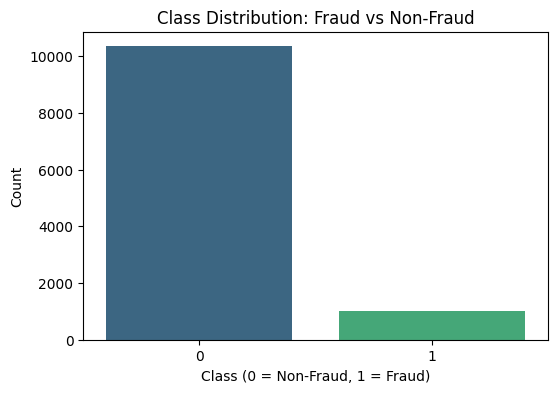

In [ ]:
# ============================================
# 1. CLASS IMBALANCE ANALYSIS
# ============================================

"""
What this reveals
How rare fraud is

Whether you need class weights or resampling

Why recall is more important than accuracy
"""



import matplotlib.pyplot as plt
import seaborn as sns

# Count fraud vs non-fraud
fraud_counts = df['is_fraud'].value_counts()

print("Fraud vs Non-Fraud Counts:")
print(fraud_counts)

# Calculate fraud rate
fraud_rate = df['is_fraud'].mean()
print(f"\nFraud Rate: {fraud_rate:.4f} ({fraud_rate*100:.2f}%)")

# Plot class distribution
plt.figure(figsize=(6,4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette="viridis")

plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()


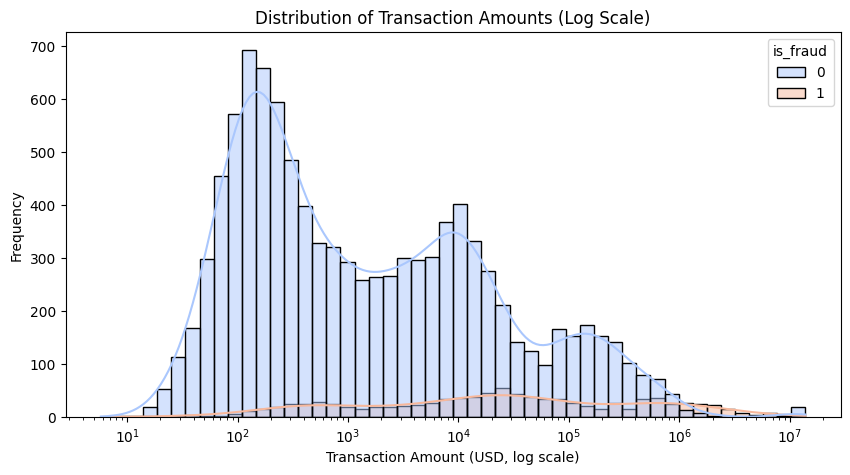

C:\Users\gideo\AppData\Local\Temp\ipykernel_43448\776241583.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


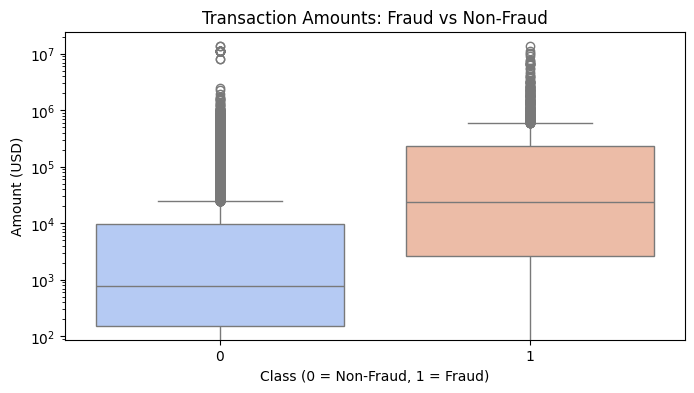

In [ ]:
# ==========================================================
# 2. TRANSACTION AMOUNT PATTERNS (Fraud vs Non-Fraud)
# ==========================================================

""""
What this reveals
Fraudsters often use small test amounts

Or very large amounts

Fraud clusters in unusual value ranges"""



plt.figure(figsize=(10,5))

# Plot distribution of transaction amounts for fraud vs non-fraud
sns.histplot(
    data=df,
    x='amount_usd',
    hue='is_fraud',
    bins=50,
    kde=True,
    palette='coolwarm',
    log_scale=True  # fraud often lives in extreme values
)

plt.title("Distribution of Transaction Amounts (Log Scale)")
plt.xlabel("Transaction Amount (USD, log scale)")
plt.ylabel("Frequency")
plt.show()

# Boxplot for clearer comparison
plt.figure(figsize=(8,4))
sns.boxplot(
    data=df,
    x='is_fraud',
    y='amount_usd',
    palette='coolwarm'
)

plt.title("Transaction Amounts: Fraud vs Non-Fraud")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Amount (USD)")
plt.yscale('log')  # helps visualize extreme values
plt.show()


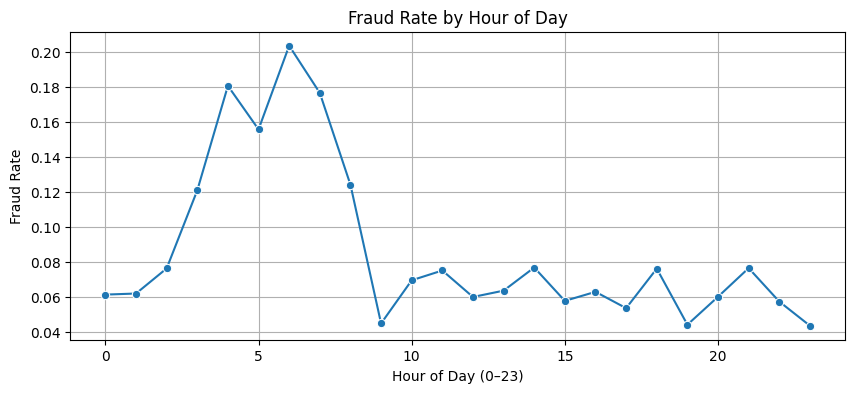

C:\Users\gideo\AppData\Local\Temp\ipykernel_43448\4216273552.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_fraud.index, y=dow_fraud.values, palette="magma")


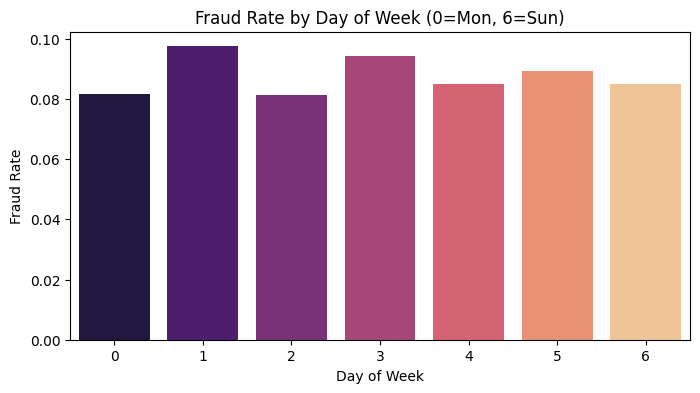

C:\Users\gideo\AppData\Local\Temp\ipykernel_43448\4216273552.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekend_fraud.index, y=weekend_fraud.values, palette="coolwarm")


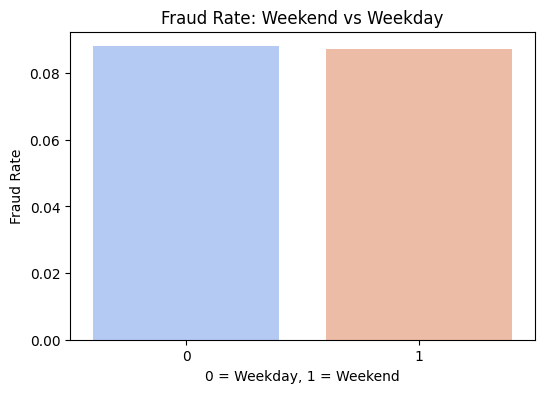

In [ ]:
# ==========================================================
# 3. TIME-BASED FRAUD BEHAVIOUR ANALYSIS
# ==========================================================



""""
What this reveals
Fraud spikes at night, weekends, or odd hours

Fraudsters behave differently from normal users

Supports your timestamp feature engineering


i will show you the preprocessing and all that i did with the data so you can create a proper app considering the pipeline.
"""

# Ensure timestamp is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract hour and day of week
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # Monday=0
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# -----------------------------
# Fraud rate by hour of day
# -----------------------------
hourly_fraud = df.groupby('hour')['is_fraud'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly_fraud.index, y=hourly_fraud.values, marker='o')
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Fraud Rate")
plt.grid(True)
plt.show()

# -----------------------------
# Fraud rate by day of week
# -----------------------------
dow_fraud = df.groupby('day_of_week')['is_fraud'].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=dow_fraud.index, y=dow_fraud.values, palette="magma")
plt.title("Fraud Rate by Day of Week (0=Mon, 6=Sun)")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate")
plt.show()

# -----------------------------
# Weekend vs Weekday Fraud Rate
# -----------------------------
weekend_fraud = df.groupby('is_weekend')['is_fraud'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=weekend_fraud.index, y=weekend_fraud.values, palette="coolwarm")
plt.title("Fraud Rate: Weekend vs Weekday")
plt.xlabel("0 = Weekday, 1 = Weekend")
plt.ylabel("Fraud Rate")
plt.show()
